# Existing-data figure/table reconstruction, print-only, corrected v3

This notebook reads the existing repository data files and displays figures/tables inline only. It does not save CSVs, PNGs, LaTeX, audit files, or output folders.

Corrections in this version:

- Spider/radar plots now avoid duplicate metric columns, so `angles` and `vals` always have matching lengths.
- Spider/radar plots use the selected best UMAP Round 2 row per site/method and plot only the five radar metrics: SC, CH, DB, Dunn, and CS.
- Voronoi panels continue to display the existing site PNGs where available, because recomputing them from annotation `x,y` alone does not reliably reproduce the manuscript figure.


In [1]:
from pathlib import Path
import re
import math
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown, Image

pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 160)

# -------------------------------------------------------------------
# Configuration
# -------------------------------------------------------------------
# Search in the current working directory and, when available, /mnt/data.
# Avoid recursive searches from filesystem roots such as / or C:\ because that can hang.
ROOT_CANDIDATES = []
for candidate in [Path.cwd(), Path('/mnt/data')]:
    try:
        if candidate.exists() and candidate not in ROOT_CANDIDATES:
            ROOT_CANDIDATES.append(candidate)
    except Exception:
        pass

SITE_ORDER = ['Duval', 'Mourachan', 'Rinyirru', 'Tarcutta', 'Undara', 'Wambiana']
SITE_DISPLAY = {
    'Duval': 'Duval-DryA',
    'Mourachan': 'Mourachan-WetA',
    'Rinyirru': 'Rinyirru-WetB',
    'Tarcutta': 'Tarcutta-DryA',
    'Undara': 'Undara-DryB',
    'Wambiana': 'Wambiana-WetA',
}

RESULT_FILES = {
    ('DBSCAN', 'PCA'): 'DBSCAN_results_round2PCA.csv',
    ('DBSCAN', 't-SNE'): 'DBSCAN_results_tsne_Round2.csv',
    ('DBSCAN', 'UMAP'): 'DBSCAN_results_round2UMAP.csv',
    ('HCA', 'PCA'): 'HCA_results_round2PCA.csv',
    ('HCA', 't-SNE'): 'HCA_results_tsne.csv',
    ('HCA', 'UMAP'): 'HCA_results_umap.csv',
    ('HDBSCAN', 'PCA'): 'HDBSCAN_results_round2PCA.csv',
    ('HDBSCAN', 't-SNE'): 'HDBSCAN_results_tsne_Round2.csv',
    ('HDBSCAN', 'UMAP'): 'HDBSCAN_results_round2UMAP.csv',
    ('KMeans', 'PCA'): 'KMeans_results_round2PCA.csv',
    ('KMeans', 't-SNE'): 'KMeans_results_tsne.csv',
    ('KMeans', 'UMAP'): 'KMeans_results_umap.csv',
}

UMAP_METHOD_FILES = {
    'HDBSCAN': 'HDBSCAN_results_round2UMAP.csv',
    'KMeans': 'KMeans_results_umap.csv',
    'DBSCAN': 'DBSCAN_results_round2UMAP.csv',
    'HCA': 'HCA_results_umap.csv',
}

METRIC_COLS = ['Silhouette', 'Calinski-Harabasz', 'Davies-Bouldin', 'Dunn', 'Composite Score']

# -------------------------------------------------------------------
# File discovery
# -------------------------------------------------------------------
def _safe_recursive_root(root):
    """Return False for filesystem roots that are too broad to rglob safely."""
    try:
        resolved = root.resolve()
    except Exception:
        resolved = root
    # POSIX root, Windows drive root, and other very broad roots should not be rglob'ed.
    if resolved == resolved.anchor:
        return False
    if str(resolved) in {'/', '\\'}:
        return False
    return True


def find_file(filename):
    """Finds a file by name in common repository locations without writing anything."""
    direct_candidates = []
    for root in ROOT_CANDIDATES:
        direct_candidates.extend([
            root / filename,
            root / 'data' / 'results' / filename,
            root / 'data' / 'figures' / filename,
            root / 'figures' / filename,
            root / 'tmpzip' / 'data' / 'results' / filename,
            root / 'tmpzip' / 'data' / 'figures' / filename,
        ])
    for p in direct_candidates:
        if p.exists():
            return p

    for root in ROOT_CANDIDATES:
        if not _safe_recursive_root(root):
            continue
        try:
            matches = list(root.rglob(filename))
            if matches:
                return matches[0]
        except Exception:
            pass
    return None


def find_many(patterns):
    matches = []
    for root in ROOT_CANDIDATES:
        for pat in patterns:
            try:
                matches.extend(root.rglob(pat))
            except Exception:
                pass
    seen = set()
    out = []
    for p in matches:
        if p.name not in seen:
            out.append(p)
            seen.add(p.name)
    return out


def parse_site(value):
    """Robustly maps row/file names to manuscript site names."""
    s = str(value)
    s_lower = s.lower()
    if 'duval' in s_lower:
        return 'Duval'
    if 'mourachan' in s_lower:
        return 'Mourachan'
    if 'rinyirru' in s_lower:
        return 'Rinyirru'
    if 'tarcutta' in s_lower:
        return 'Tarcutta'
    if 'undara' in s_lower:
        return 'Undara'
    if 'wambiana' in s_lower:
        return 'Wambiana'
    return s


def standardise_result_df(df, method, dr, source_file):
    df = df.copy()
    rename = {
        'Silhouette Coefficient': 'Silhouette',
        'Dunn-Index': 'Dunn',
    }
    df = df.rename(columns=rename)
    df['method'] = method
    df['dr'] = dr
    df['source_file'] = source_file
    df['site'] = df['Unnamed: 0'].apply(parse_site)
    df['site_display'] = df['site'].map(SITE_DISPLAY).fillna(df['site'])
    for col in METRIC_COLS:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')
    return df


def load_round2_results(result_files=RESULT_FILES):
    frames = []
    missing = []
    for (method, dr), fname in result_files.items():
        path = find_file(fname)
        if path is None:
            missing.append(fname)
            continue
        df = pd.read_csv(path)
        frames.append(standardise_result_df(df, method, dr, fname))
    if missing:
        print('Missing files:', missing)
    if not frames:
        raise FileNotFoundError('No Round 2 result CSVs were found.')
    return pd.concat(frames, ignore_index=True)

raw_round2 = load_round2_results()
display(Markdown('## Loaded Round 2 result files'))
display(raw_round2.groupby(['dr', 'method', 'source_file']).size().reset_index(name='rows'))


## Loaded Round 2 result files

,dr,method,source_file,rows
0,PCA,DBSCAN,DBSCAN_results_round2PCA.csv,6
1,PCA,HCA,HCA_results_round2PCA.csv,6
2,PCA,HDBSCAN,HDBSCAN_results_round2PCA.csv,6
3,PCA,KMeans,KMeans_results_round2PCA.csv,6
4,UMAP,DBSCAN,DBSCAN_results_round2UMAP.csv,96
5,UMAP,HCA,HCA_results_umap.csv,54
6,UMAP,HDBSCAN,HDBSCAN_results_round2UMAP.csv,96
7,UMAP,KMeans,KMeans_results_umap.csv,54
8,t-SNE,DBSCAN,DBSCAN_results_tsne_Round2.csv,18
9,t-SNE,HCA,HCA_results_tsne.csv,18


## Combined normalised internal metric table

,source_file,Unnamed: 0,site,site_display,method,dr,Raw Score,Metric,Transformed Score,Score_norm
0,DBSCAN_results_round2PCA.csv,39-features-Duval-DryA-20min-full-day,Duval,Duval-DryA,DBSCAN,PCA,0.210112,Silhouette,0.210112,0.652643
1,DBSCAN_results_round2PCA.csv,39-features-Mourachan-WetA-20min-full-day,Mourachan,Mourachan-WetA,DBSCAN,PCA,0.248552,Silhouette,0.248552,0.673375
2,DBSCAN_results_round2PCA.csv,39-features-Rinyirru-WetB-20min-full-day,Rinyirru,Rinyirru-WetB,DBSCAN,PCA,0.117927,Silhouette,0.117927,0.602926
3,DBSCAN_results_round2PCA.csv,39-features-Undara-DryB-20min-full-day,Undara,Undara-DryB,DBSCAN,PCA,0.092179,Silhouette,0.092179,0.589039
4,DBSCAN_results_round2PCA.csv,39-features-Wambiana-WetA-20min-full-day,Wambiana,Wambiana-WetA,DBSCAN,PCA,0.202289,Silhouette,0.202289,0.648424
5,DBSCAN_results_round2PCA.csv,Tarcutta-DryA-20210430,Tarcutta,Tarcutta-DryA,DBSCAN,PCA,0.241411,Silhouette,0.241411,0.669524
6,DBSCAN_results_tsne_Round2.csv,39-features-Duval-DryA-20min-full-day_perplexi...,Duval,Duval-DryA,DBSCAN,t-SNE,-0.343804,Silhouette,-0.343804,0.353903
7,DBSCAN_results_tsne_Round2.csv,39-features-Duval-DryA-20min-full-day_perplexi...,Duval,Duval-DryA,DBSCAN,t-SNE,-0.377775,Silhouette,-0.377775,0.335581
8,DBSCAN_results_tsne_Round2.csv,39-features-Duval-DryA-20min-full-day_perplexi...,Duval,Duval-DryA,DBSCAN,t-SNE,-0.485928,Silhouette,-0.485928,0.277252
9,DBSCAN_results_tsne_Round2.csv,39-features-Mourachan-WetA-20min-full-day_perp...,Mourachan,Mourachan-WetA,DBSCAN,t-SNE,-0.385720,Silhouette,-0.385720,0.331297


## Best internal result per site, based on manuscript-style best configuration

,site_display,method,dr,Best approach,Silhouette,Calinski-Harabasz,Davies-Bouldin,Dunn,Composite Score
223,Duval-DryA,HDBSCAN,UMAP,"min_cluster_size=5, min_samples=2",0.238100,317.915057,0.871408,0.111591,4.0
238,Mourachan-WetA,HDBSCAN,UMAP,"min_cluster_size=5, min_samples=2",0.629617,4039.231267,0.439054,0.067109,4.0
320,Rinyirru-WetB,KMeans,PCA,3,0.415514,2004.701100,0.981471,0.043136,4.0
314,Tarcutta-DryA,HDBSCAN,UMAP,"min_cluster_size=5, min_samples=2",0.630954,7740.708788,0.426585,0.333656,4.0
285,Undara-DryB,HDBSCAN,UMAP,"min_cluster_size=5, min_samples=2",0.606861,1852.615189,0.388479,0.592774,4.0
290,Wambiana-WetA,HDBSCAN,UMAP,"min_cluster_size=5, min_samples=2",0.793620,16438.295714,0.247958,0.397160,4.0


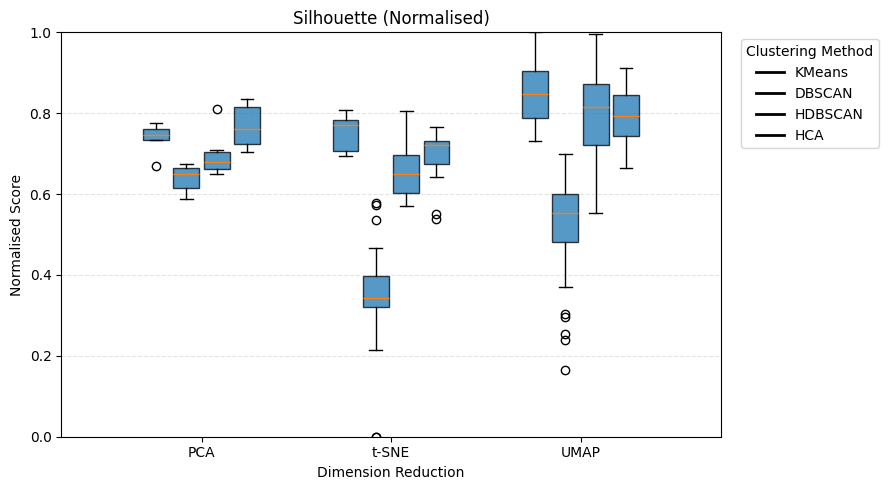

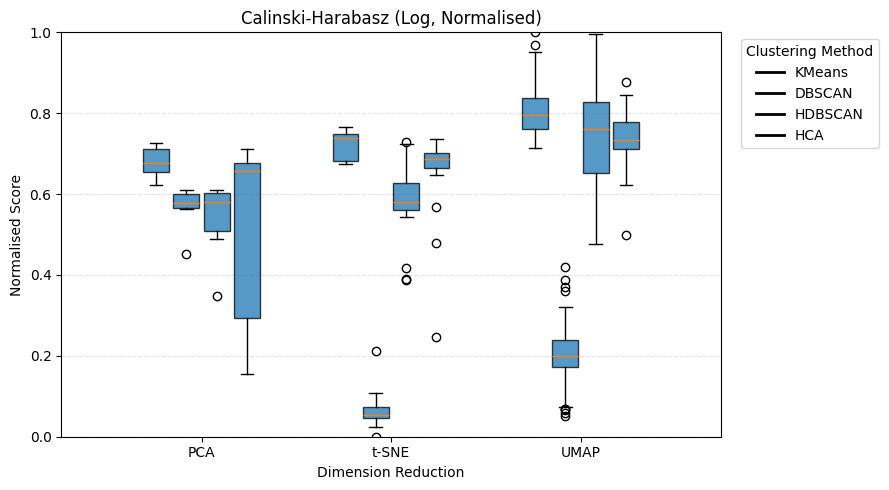

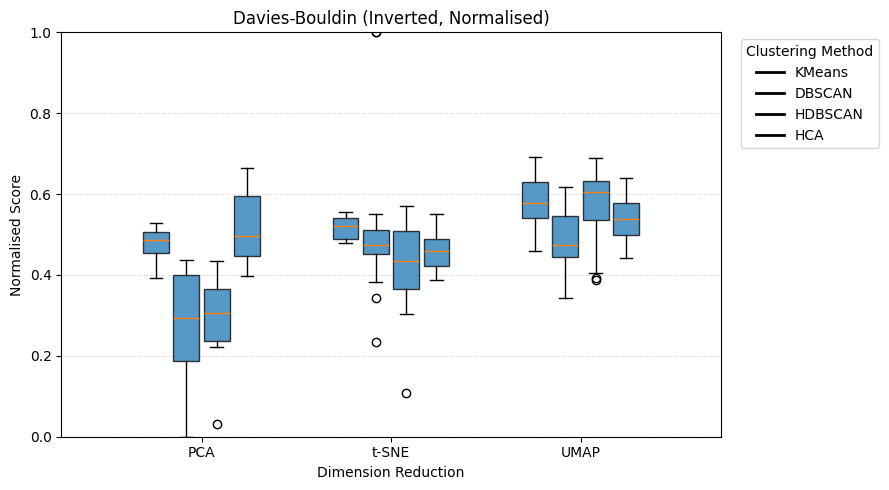

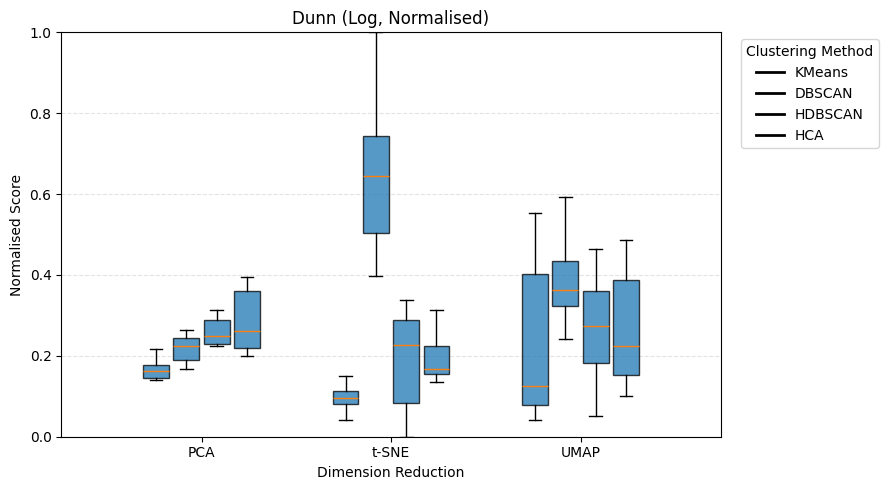

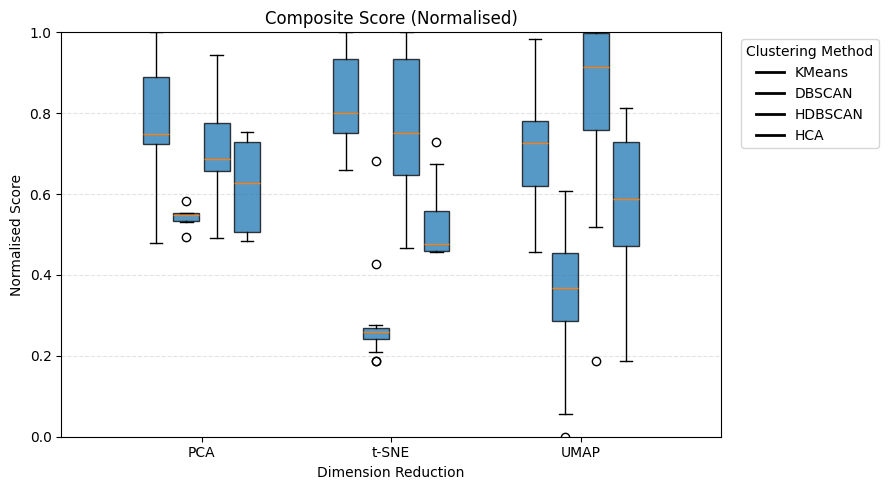

In [2]:

# -------------------------------------------------------------------
# Internal metric tables and Figure 2-style boxplots
# -------------------------------------------------------------------
def transform_for_display(metric, values):
    values = pd.to_numeric(values, errors='coerce').astype(float)
    if metric == 'Calinski-Harabasz':
        values = values.mask(values <= 0, np.nan)
        return np.log(values)
    if metric == 'Dunn':
        values = values.mask(values <= 0, np.nan)
        return np.log(values)
    if metric == 'Davies-Bouldin':
        return -values
    return values


def minmax(values):
    values = pd.to_numeric(values, errors='coerce').astype(float)
    mn = values.min(skipna=True)
    mx = values.max(skipna=True)
    if pd.isna(mn) or pd.isna(mx):
        return pd.Series(np.nan, index=values.index)
    if np.isclose(mx, mn):
        return pd.Series(0.5, index=values.index)
    return (values - mn) / (mx - mn)

metric_rows = []
for metric in METRIC_COLS:
    if metric not in raw_round2.columns:
        continue
    tmp = raw_round2[['source_file', 'Unnamed: 0', 'site', 'site_display', 'method', 'dr', metric]].copy()
    tmp = tmp.rename(columns={metric: 'Raw Score'})
    tmp['Metric'] = metric
    tmp['Transformed Score'] = transform_for_display(metric, tmp['Raw Score'])
    tmp['Score_norm'] = minmax(tmp['Transformed Score'])
    metric_rows.append(tmp)

normalized_round2 = pd.concat(metric_rows, ignore_index=True)

display(Markdown('## Combined normalised internal metric table'))
display(normalized_round2.head(20))

display(Markdown('## Best internal result per site, based on manuscript-style best configuration'))
best_internal = (
    raw_round2
    .sort_values('Composite Score', ascending=False)
    .groupby('site', as_index=False)
    .head(1)
    .sort_values('site')
)
display(best_internal[['site_display', 'method', 'dr', 'Best approach', 'Silhouette', 'Calinski-Harabasz', 'Davies-Bouldin', 'Dunn', 'Composite Score']])

# Boxplots use all available Round 2 rows, not only best rows.
METHOD_ORDER = ['KMeans', 'DBSCAN', 'HDBSCAN', 'HCA']
DR_ORDER = ['PCA', 't-SNE', 'UMAP']
metric_titles = {
    'Silhouette': 'Silhouette (Normalised)',
    'Calinski-Harabasz': 'Calinski-Harabasz (Log, Normalised)',
    'Davies-Bouldin': 'Davies-Bouldin (Inverted, Normalised)',
    'Dunn': 'Dunn (Log, Normalised)',
    'Composite Score': 'Composite Score (Normalised)',
}

for metric in METRIC_COLS:
    plot_df = normalized_round2[normalized_round2['Metric'] == metric].dropna(subset=['Score_norm'])
    if plot_df.empty:
        continue
    fig, ax = plt.subplots(figsize=(9, 5))
    width = 0.16
    x_positions = np.arange(len(DR_ORDER))
    boxes = []
    positions = []
    for m_i, method in enumerate(METHOD_ORDER):
        offset = (m_i - (len(METHOD_ORDER)-1)/2) * width
        for d_i, dr in enumerate(DR_ORDER):
            vals = plot_df[(plot_df['method'] == method) & (plot_df['dr'] == dr)]['Score_norm'].dropna().values
            boxes.append(vals)
            positions.append(x_positions[d_i] + offset)
    bp = ax.boxplot(boxes, positions=positions, widths=width*0.85, patch_artist=True, showfliers=True)
    for patch in bp['boxes']:
        patch.set_alpha(0.75)
    ax.set_xticks(x_positions)
    ax.set_xticklabels(DR_ORDER)
    ax.set_ylim(0, 1)
    ax.set_xlabel('Dimension Reduction')
    ax.set_ylabel('Normalised Score')
    ax.set_title(metric_titles.get(metric, metric))
    ax.grid(axis='y', linestyle='--', alpha=0.35)
    handles = [plt.Line2D([0], [0], color='black', linewidth=2, label=m) for m in METHOD_ORDER]
    ax.legend(handles=handles, title='Clustering Method', bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.tight_layout()
    plt.show()


## Table 2-style post-hoc GT/external validation table

,Dataset,Accuracy,Precision,Recall,F1-score,MACPC,# Sound Types,# Clusters,Sound Types Present
0,Undara,0.848,0.839,0.848,0.837,1.525,8,18,"birds, frogs, human_speech, insects, misc/unce..."
1,Duval,0.898,0.849,0.898,0.870,1.430,9,15,"birds, human_speech, insects, mammals, misc/un..."
2,Rinyirru,0.940,0.959,0.940,0.945,1.227,6,12,"birds, insects, mammals, misc/uncertain, vehic..."
3,Mourachan,0.954,0.914,0.954,0.933,1.723,10,19,"birds, frogs, insects, mammals, misc/uncertain..."
4,Wambiana,0.985,0.982,0.985,0.983,1.100,4,6,"insects, birds, wind_light, wind_strong"
5,Tarcutta,0.930,0.920,0.930,0.925,1.350,5,10,"insects, birds, rain_heavy, wind_light, wind_s..."


## Figure 5-style Voronoi/site panels

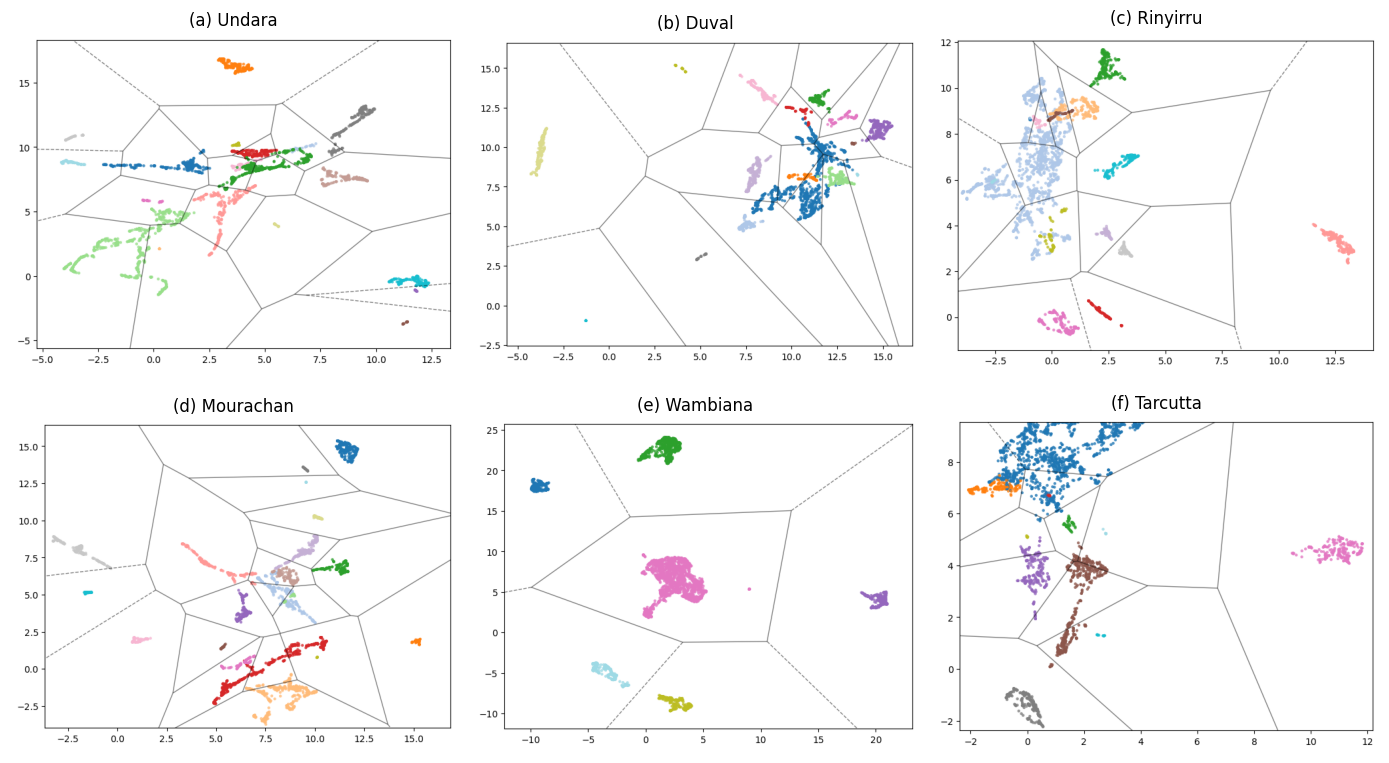

In [4]:

# -------------------------------------------------------------------
# GT/external table, print-only, using manuscript reference values
# -------------------------------------------------------------------
external_table = pd.DataFrame([
    {'Dataset': 'Undara', 'Accuracy': 0.848, 'Precision': 0.839, 'Recall': 0.848, 'F1-score': 0.837, 'MACPC': 1.525, '# Sound Types': 8, '# Clusters': 18, 'Sound Types Present': 'birds, frogs, human_speech, insects, misc/uncertain, rain_light, vehicles, wind_light'},
    {'Dataset': 'Duval', 'Accuracy': 0.898, 'Precision': 0.849, 'Recall': 0.898, 'F1-score': 0.870, 'MACPC': 1.430, '# Sound Types': 9, '# Clusters': 15, 'Sound Types Present': 'birds, human_speech, insects, mammals, misc/uncertain, rain_heavy, rain_light, vehicles, wind_light'},
    {'Dataset': 'Rinyirru', 'Accuracy': 0.940, 'Precision': 0.959, 'Recall': 0.940, 'F1-score': 0.945, 'MACPC': 1.227, '# Sound Types': 6, '# Clusters': 12, 'Sound Types Present': 'birds, insects, mammals, misc/uncertain, vehicles, wind_light'},
    {'Dataset': 'Mourachan', 'Accuracy': 0.954, 'Precision': 0.914, 'Recall': 0.954, 'F1-score': 0.933, 'MACPC': 1.723, '# Sound Types': 10, '# Clusters': 19, 'Sound Types Present': 'birds, frogs, insects, mammals, misc/uncertain, rain_heavy, rain_light, vehicles, wind_strong, wind_light'},
    {'Dataset': 'Wambiana', 'Accuracy': 0.985, 'Precision': 0.982, 'Recall': 0.985, 'F1-score': 0.983, 'MACPC': 1.100, '# Sound Types': 4, '# Clusters': 6, 'Sound Types Present': 'insects, birds, wind_light, wind_strong'},
    {'Dataset': 'Tarcutta', 'Accuracy': 0.930, 'Precision': 0.920, 'Recall': 0.930, 'F1-score': 0.925, 'MACPC': 1.350, '# Sound Types': 5, '# Clusters': 10, 'Sound Types Present': 'insects, birds, rain_heavy, wind_light, wind_strong'},
])
external_table['Dataset'] = pd.Categorical(external_table['Dataset'], categories=['Undara', 'Duval', 'Rinyirru', 'Mourachan', 'Wambiana', 'Tarcutta'], ordered=True)
external_table = external_table.sort_values('Dataset')

display(Markdown('## Table 2-style post-hoc GT/external validation table'))
display(external_table)

# -------------------------------------------------------------------
# Voronoi panels
# -------------------------------------------------------------------
# Exact Voronoi reproduction needs the exact UMAP coordinates, cluster assignments, colour mapping,
# and plotting choices used for the manuscript. In this existing-data, print-only notebook, the safest
# option is to display the existing site PNGs when they are present. If they are not present, a fallback
# recomputation from annotation x/y/class can be added, but it will not necessarily match the manuscript.

display(Markdown('## Figure 5-style Voronoi/site panels'))

site_image_names = {
    'Undara': 'Undara.png',
    'Duval': 'Duval.png',
    'Rinyirru': 'Rinyirru.png',
    'Mourachan': 'Mourachan.png',
    'Wambiana': 'Wambiana.png',
    'Tarcutta': 'Tarcutta.png',
}

# Display existing figure files as a combined panel when available.
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.ravel()
panel_order = ['Undara', 'Duval', 'Rinyirru', 'Mourachan', 'Wambiana', 'Tarcutta']
panel_labels = ['(a)', '(b)', '(c)', '(d)', '(e)', '(f)']
any_image = False
for ax, site, lab in zip(axes, panel_order, panel_labels):
    img_path = find_file(site_image_names[site])
    if img_path is None:
        ax.axis('off')
        ax.set_title(f'{lab} {site} image not found')
        continue
    img = plt.imread(img_path)
    ax.imshow(img)
    ax.axis('off')
    ax.set_title(f'{lab} {site}')
    any_image = True
plt.tight_layout()
plt.show()

if not any_image:
    print('No existing Voronoi/site image files were found. The notebook did not recompute them because that will not match the manuscript exactly without the original plotting inputs.')


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# === Data ===
samples = np.array([100, 562, 3162, 17782, 100000])
t_sne_time = np.array([0.20, 0.49, 8.31, 62.40, 596.05])
umap_time = np.array([0.47, 0.95, 5.24, 6.66, 56.02])
pca_time  = np.array([0.00, 0.00, 0.01, 0.02, 0.10])
hdbscan_time = np.array([0.00, 0.01, 0.14, 7.85, 151.54])

# === Total processing times (in seconds) ===
total_tsne = hdbscan_time + t_sne_time
total_umap = hdbscan_time + umap_time
total_pca = hdbscan_time + pca_time

# Updated multipliers based on derived approximations
# LAMDA is ~3.4x slower than UMAP baseline
# MEC is ~22x slower than UMAP baseline
total_mec = total_umap * 22.0
total_lamda = total_umap * 3.4

# === Fit log-log models ===
fit_tsne = np.polyfit(np.log10(samples), np.log10(total_tsne), deg=2)
fit_umap = np.polyfit(np.log10(samples), np.log10(total_umap), deg=2)
fit_pca = np.polyfit(np.log10(samples), np.log10(total_pca + 0.9e-4), deg=2)
fit_mec = np.polyfit(np.log10(samples), np.log10(total_mec), deg=2)
fit_lamda = np.polyfit(np.log10(samples), np.log10(total_lamda), deg=2)

# === Extrapolation to 10^6 samples ===
sample_range = np.logspace(2, 6, 300)

def extrapolate(fit, x):
    return 10 ** np.polyval(fit, np.log10(x))

seconds_to_minutes = 1.0 / 60.0
tsne_min = extrapolate(fit_tsne, sample_range) * seconds_to_minutes
umap_min = extrapolate(fit_umap, sample_range) * seconds_to_minutes
pca_min = extrapolate(fit_pca, sample_range) * seconds_to_minutes
mec_min = extrapolate(fit_mec, sample_range) * seconds_to_minutes
lamda_min = extrapolate(fit_lamda, sample_range) * seconds_to_minutes

# === Split point for solid vs dotted ===
split_idx = np.searchsorted(sample_range, 1e4)

# === Plot ===
plt.figure(figsize=(10, 6))

# HDBSCAN + t-SNE
plt.plot(sample_range[:split_idx], tsne_min[:split_idx], '-', label="Ours(t-SNE)", color='blue')
plt.plot(sample_range[split_idx:], tsne_min[split_idx:], ':', color='blue')

# HDBSCAN + UMAP
plt.plot(sample_range[:split_idx], umap_min[:split_idx], '-', label="Ours(UMAP)", color='green')
plt.plot(sample_range[split_idx:], umap_min[split_idx:], ':', color='green')

# HDBSCAN + PCA
plt.plot(sample_range[:split_idx], pca_min[:split_idx], '-', label="Ours(PCA)", color='red')
plt.plot(sample_range[split_idx:], pca_min[split_idx:], ':', color='red')

# MEC and LAMDA (always dotted)
plt.plot(sample_range, mec_min, ':', label="Meta-Embedded Clustering (MEC)", color='orange')
plt.plot(sample_range, lamda_min, ':', label="LAMDA 3π", color='purple')

# === Axes and legend ===
plt.xlabel("Number of Samples")
plt.ylabel("Processing Time (minutes)")
plt.xscale("log")
plt.xlim(1e2, 1e6)

ymax = max(lamda_min.max(), mec_min.max(), tsne_min.max(), umap_min.max(), pca_min.max())
plt.ylim(-1, ymax * 0.015)

plt.legend()
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.tight_layout()
plt.show()